# Data Card

### About Dataset

## Context
#### US Airline passenger satisfaction survey -https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data

## Content
#### Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)
#### Age: The actual age of the passengers
#### Gender: Gender of the passengers (Female, Male)
#### Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)"
#### Class:Travel class in the plane of the passengers (Business, Eco, Eco Plus)"
#### Customer Type:The customer type (Loyal customer, disloyal customer)
#### Flight distance:The flight distance of this journey
#### Inflight wifi service:Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)"
#### Ease of Online booking:Satisfaction level of online booking
#### Inflight service:Satisfaction level of inflight service
#### Online boarding:Satisfaction level of online boarding
#### Inflight entertainment:Satisfaction level of inflight entertainment
#### Food and drink:Satisfaction level of Food and drink
#### Seat comfort:Satisfaction level of Seat comfort
#### On-board service:Satisfaction level of On-board service
#### Leg room service:Satisfaction level of Leg room service
#### Departure/Arrival time convenient:Satisfaction level of Departure/Arrival time convenient
#### Baggage handling:Satisfaction level of baggage handling
#### Gate location:Satisfaction level of Gate location
#### Cleanliness:Satisfaction level of Cleanliness
#### Check-in service:Satisfaction level of Check-in service
#### Departure Delay in Minutes:Minutes delayed when departure
#### Arrival Delay in Minutes:Minutes delayed when Arrival
#### Flight cancelled:Whether the Flight cancelled or not (Yes, No)
#### Flight time in minutes:Minutes of Flight takes


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import myfunctions as mf # my module
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
importlib.reload(mf) # reload my functions if any update is made 

<module 'myfunctions' from 'C:\\Users\\igyan\\Desktop\\DS\\PROJECTS\\passenger_satisfaction_prediction-model\\myfunctions.py'>

# Load Dataset

In [2]:
# file located on my local machine
file_path = r"C:\\Users\\igyan\\Desktop/DS/PROJECTS/passenger_satisfaction_prediction-model/satisfaction.csv"
user_df = pd.read_csv(file_path)

# print the first 5 rows
user_df.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0


# Dataset Overview

In [3]:
# Dataset Info
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   satisfaction_v2                    129880 non-null  object 
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Seat comfort                       129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Gate location                      1298

In [4]:
# checking for missing values
print('Missing Values:\n')
user_df.isnull().sum()

Missing Values:



id                                     0
satisfaction_v2                        0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [5]:
# check for duplicate rows in dataset
user_df.duplicated().any()

np.False_

In [6]:
# check for outliers 
mf.check_for_outliers(user_df)

id                                       0
Age                                      0
Flight Distance                       2581
Seat comfort                             0
Departure/Arrival time convenient        0
Food and drink                           0
Gate location                            0
Inflight wifi service                    0
Inflight entertainment                   0
Online support                           0
Ease of Online booking                   0
On-board service                     13270
Leg room service                         0
Baggage handling                         0
Checkin service                      15370
Cleanliness                              0
Online boarding                          0
Departure Delay in Minutes           18098
Arrival Delay in Minutes             17492
dtype: int64


In [7]:
# check for value inconsistency (capitalization, spacing)  in categorical columns
categorical_cols = user_df.select_dtypes(include = ['object']).columns

# loop through categorical columns to get their values

for col in categorical_cols:
    unique_values =user_df[col].unique() # get unique values of each column
    print(f"unique values in {col} are:{unique_values}\n")

unique values in satisfaction_v2 are:['satisfied' 'neutral or dissatisfied']

unique values in Gender are:['Female' 'Male']

unique values in Customer Type are:['Loyal Customer' 'disloyal Customer']

unique values in Type of Travel are:['Personal Travel' 'Business travel']

unique values in Class are:['Eco' 'Business' 'Eco Plus']



# Data Cleaning

### standardizing column name

In [8]:
# standardize column names using the snakecase format (lowercase and underscore)
mf.format_column_name(user_df)

standardized columns names:



['id',
 'satisfaction_v2',
 'gender',
 'customer_type',
 'age',
 'type_of_travel',
 'class',
 'flight_distance',
 'seat_comfort',
 'departure/arrival_time_convenient',
 'food_and_drink',
 'gate_location',
 'inflight_wifi_service',
 'inflight_entertainment',
 'online_support',
 'ease_of_online_booking',
 'on-board_service',
 'leg_room_service',
 'baggage_handling',
 'checkin_service',
 'cleanliness',
 'online_boarding',
 'departure_delay_in_minutes',
 'arrival_delay_in_minutes']

### Imputing Missing Values

In [9]:
# imputing missing values in arrival_delay_in_minutes column using the mean
user_df['arrival_delay_in_minutes'] = user_df['arrival_delay_in_minutes']. \
                                    fillna(user_df['arrival_delay_in_minutes'].mean())

# verify if dataset has no missing values 
user_df.isnull().sum().any()

np.False_

### Handling outliers using vectorization

In [10]:
# handle outliers using lowerbound and upperbound values as replacement
mf.handle_outliers(user_df)

# verify if there are no outliers
mf.check_for_outliers(user_df)

Outliers capped successfully.

id                                   0
age                                  0
flight_distance                      0
seat_comfort                         0
departure/arrival_time_convenient    0
food_and_drink                       0
gate_location                        0
inflight_wifi_service                0
inflight_entertainment               0
online_support                       0
ease_of_online_booking               0
on-board_service                     0
leg_room_service                     0
baggage_handling                     0
checkin_service                      0
cleanliness                          0
online_boarding                      0
departure_delay_in_minutes           0
arrival_delay_in_minutes             0
dtype: int64


## Handling value inconsistency (capitalization) in catergorical columns 

In [11]:
# check for value inconsistency (capitalization, spacing)  in categorical columns
categorical_cols = user_df.select_dtypes(include = ['object']).columns #select categorical columns

# loop through categorical columns to clean capitalization and spacing issues
for col in categorical_cols:
    if col in user_df.columns:
        user_df[col] = user_df[col].str.strip().str.lower()
    else:
        print(f"Column '{col}' not found in DataFrame.")

# loop through categorical columns to verify if the issues are corrected
for col in categorical_cols:
    unique_values =user_df[col].unique() # get unique values of each column
    print(f"unique values in {col} are:{unique_values}\n")

unique values in satisfaction_v2 are:['satisfied' 'neutral or dissatisfied']

unique values in gender are:['female' 'male']

unique values in customer_type are:['loyal customer' 'disloyal customer']

unique values in type_of_travel are:['personal travel' 'business travel']

unique values in class are:['eco' 'business' 'eco plus']



# Exploratory Data Analysis

In [12]:
# summary of dataset
user_df.describe()

,id,age,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1969.775073,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.516200,3.485902,3.695673,3.399985,3.705759,3.352587,7.380798,7.955049
std,37493.270818,15.119360,994.672868,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.177227,1.292226,1.156483,1.156760,1.151774,1.298715,11.209935,11.969676
min,1.000000,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,0.000000,1.000000,1.500000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,97410.250000,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4321.500000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,30.000000,32.500000


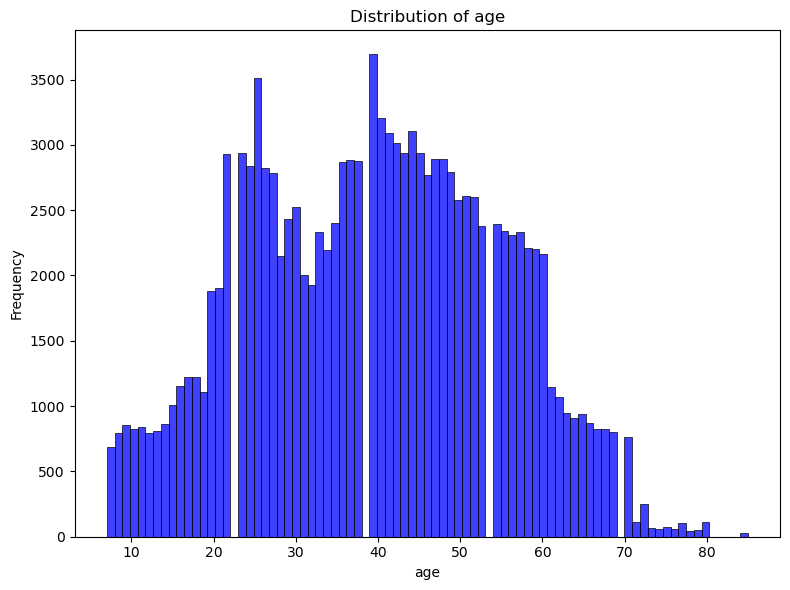

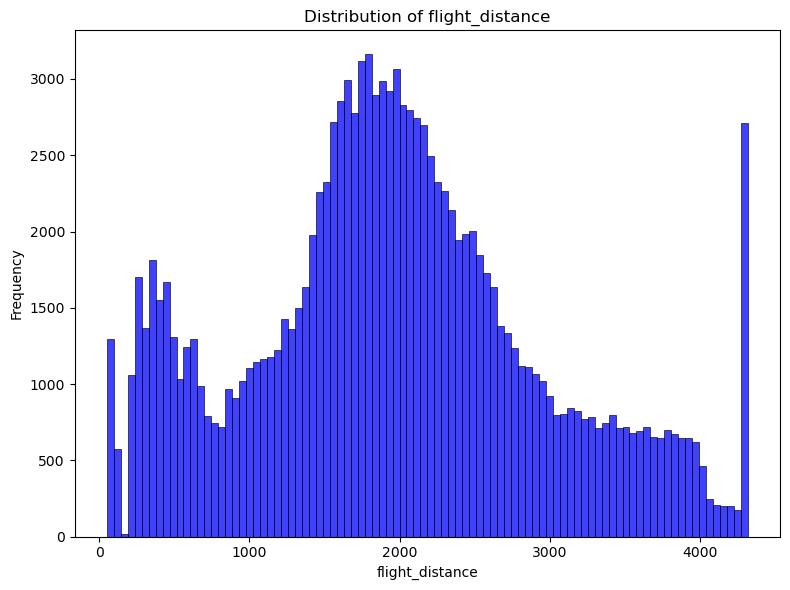

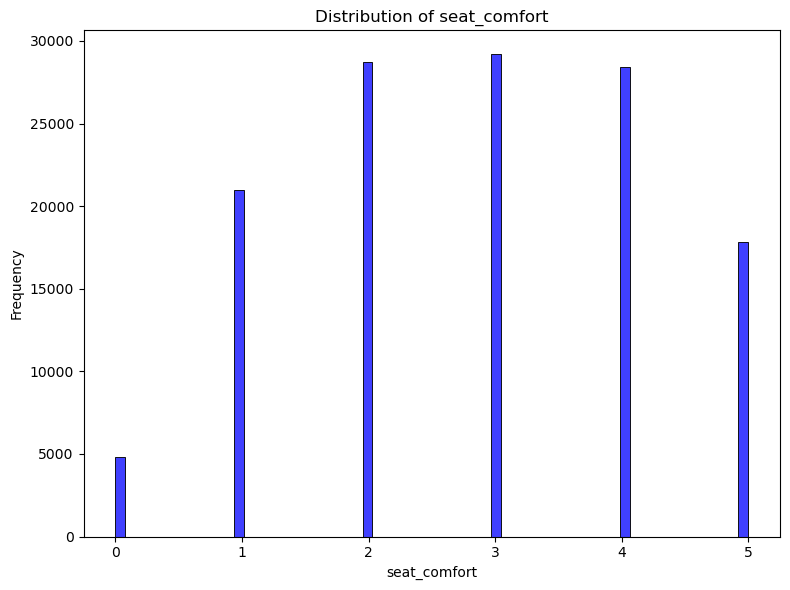

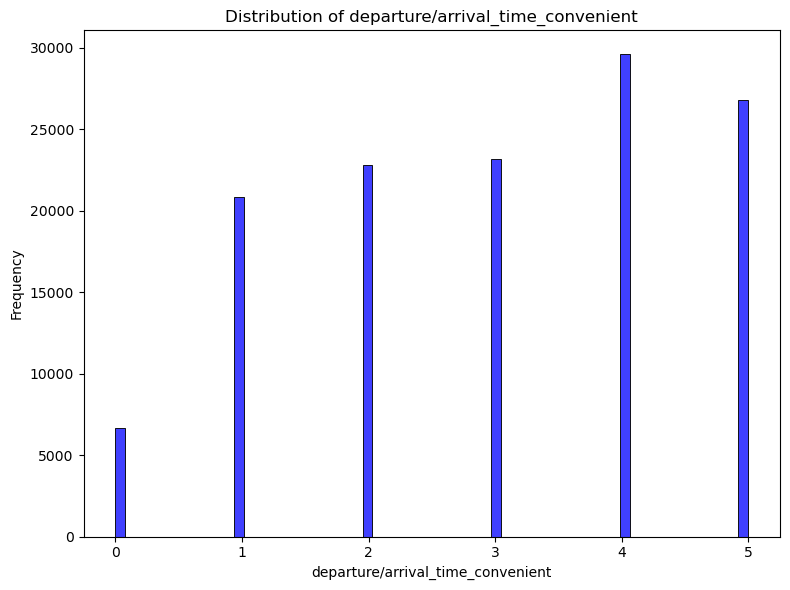

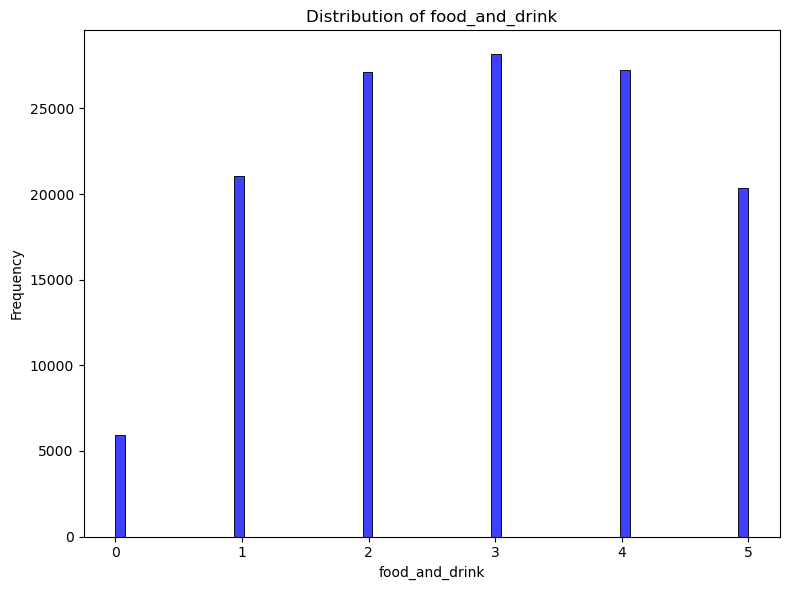

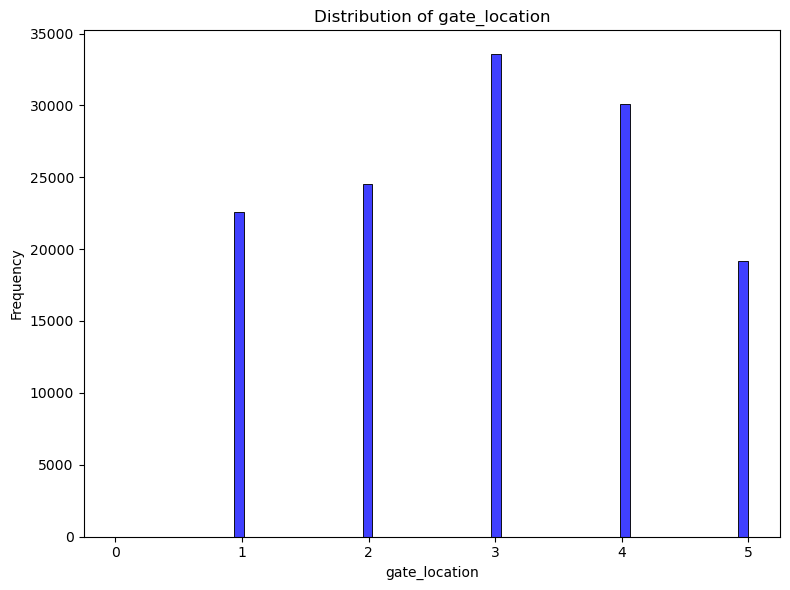

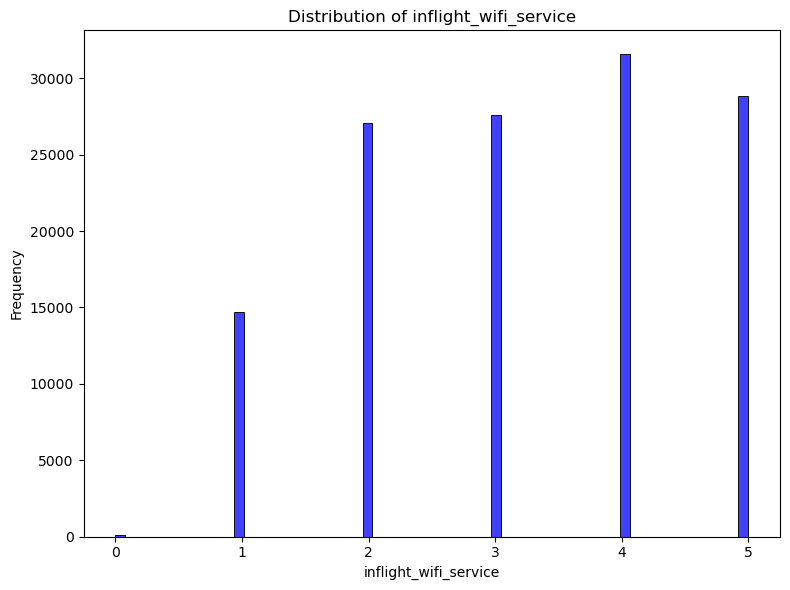

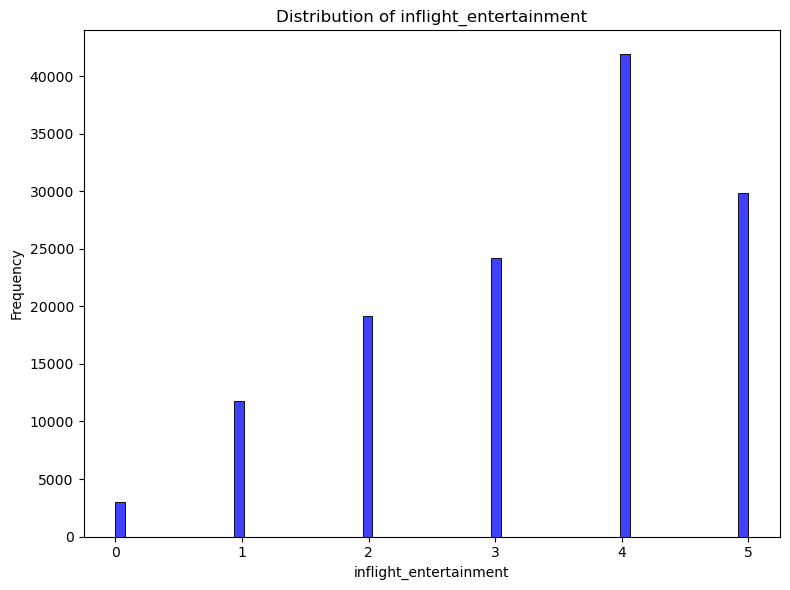

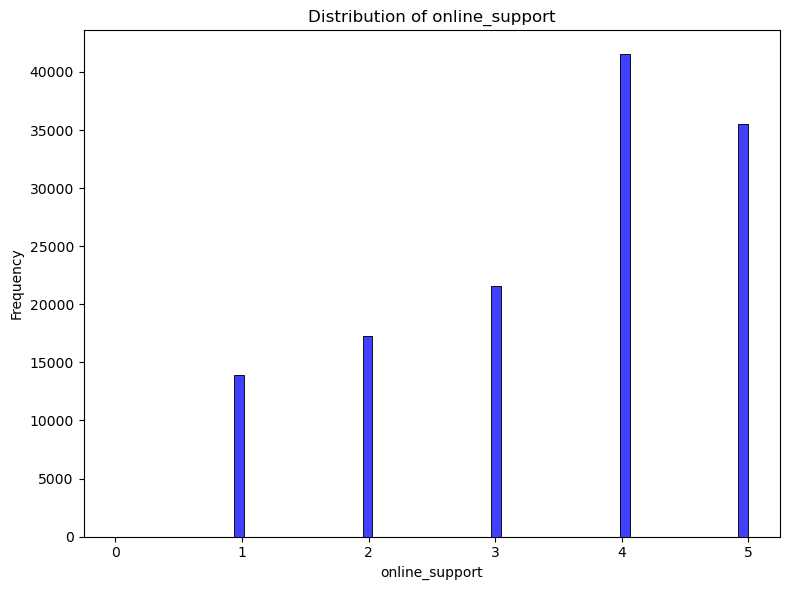

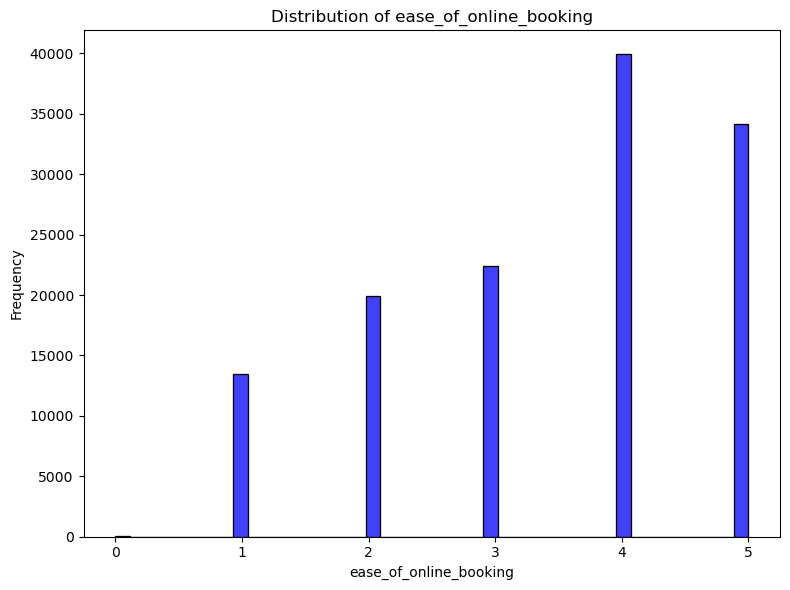

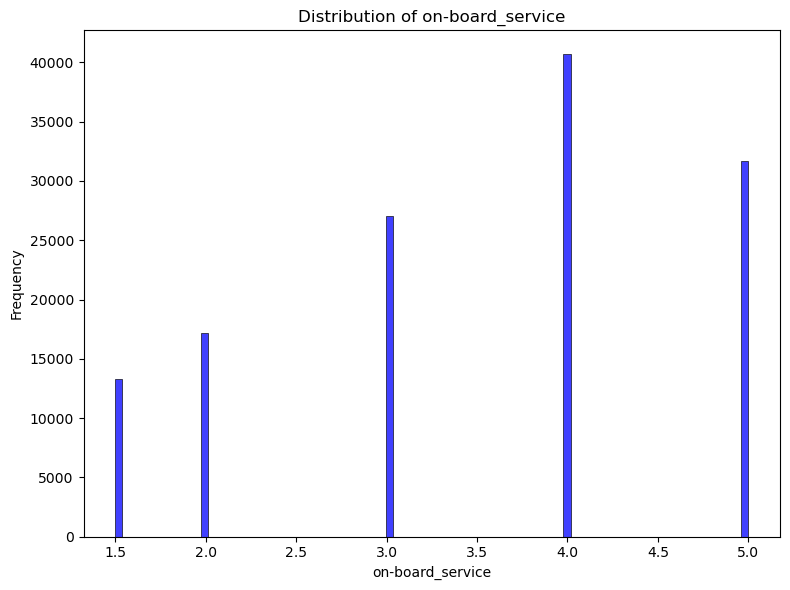

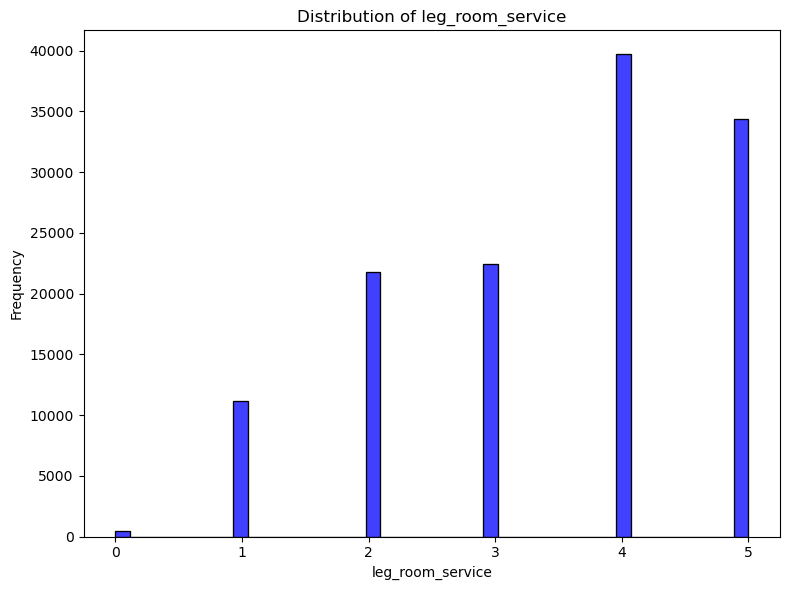

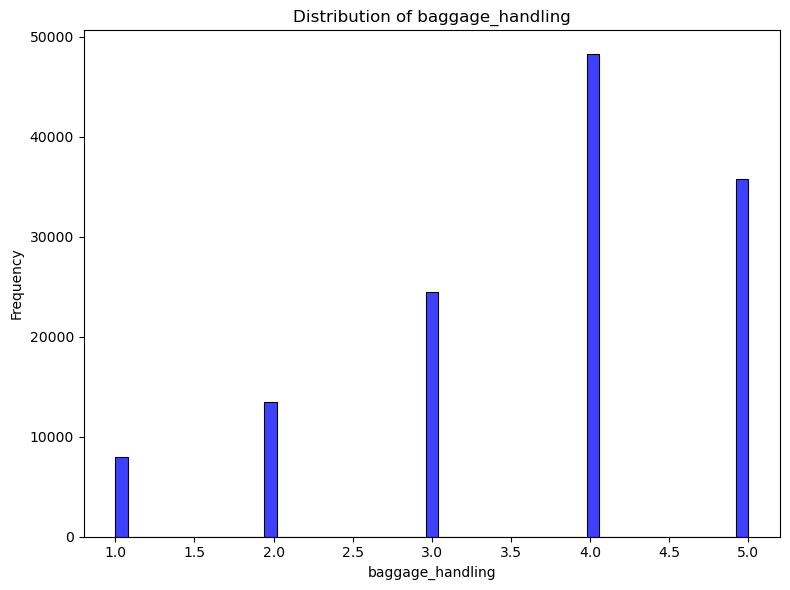

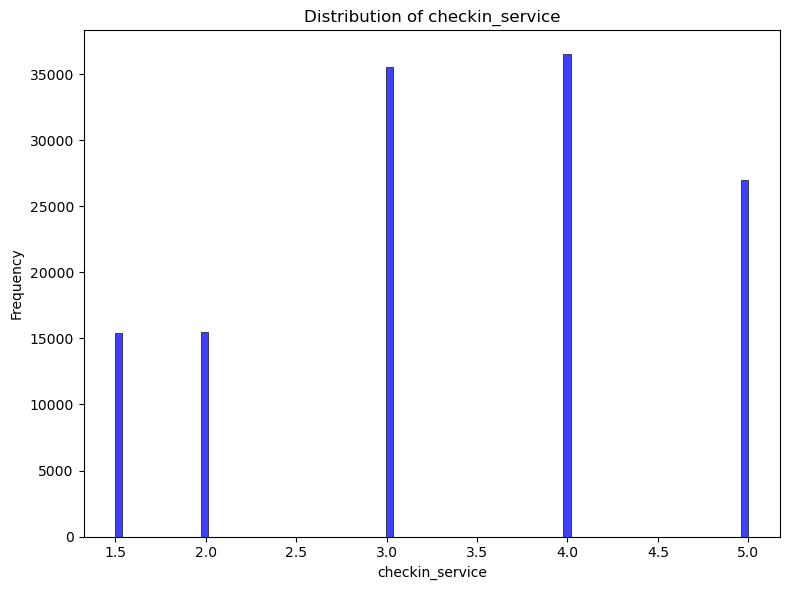

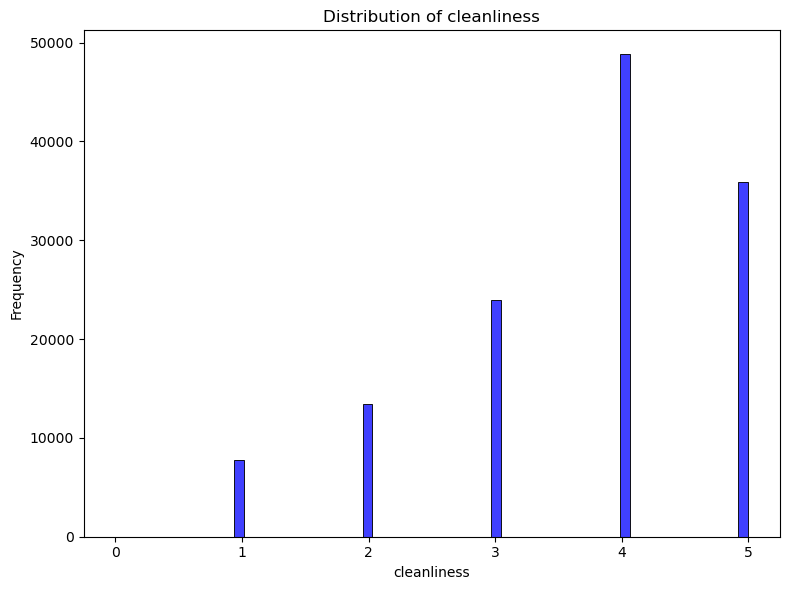

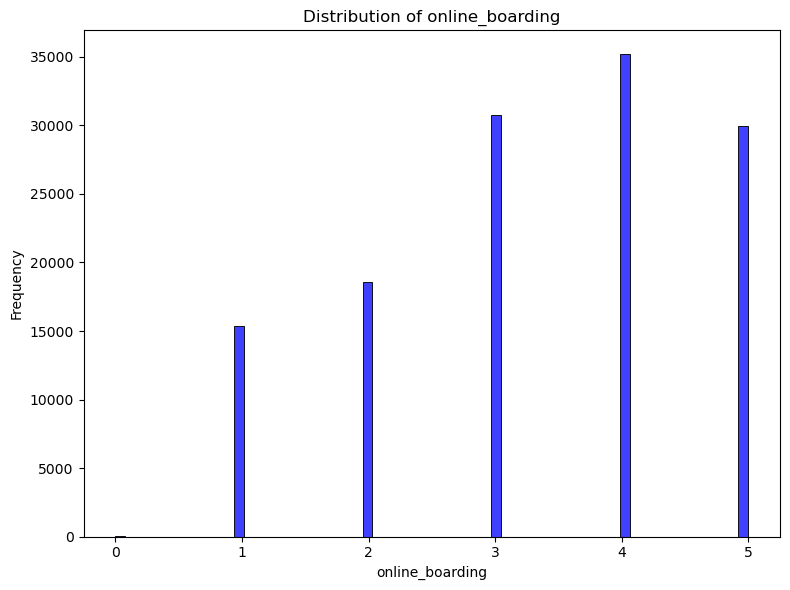

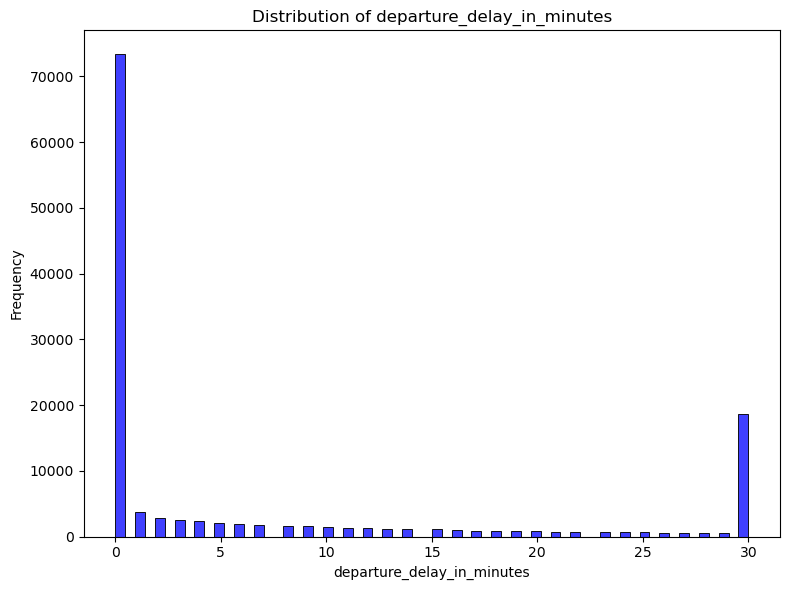

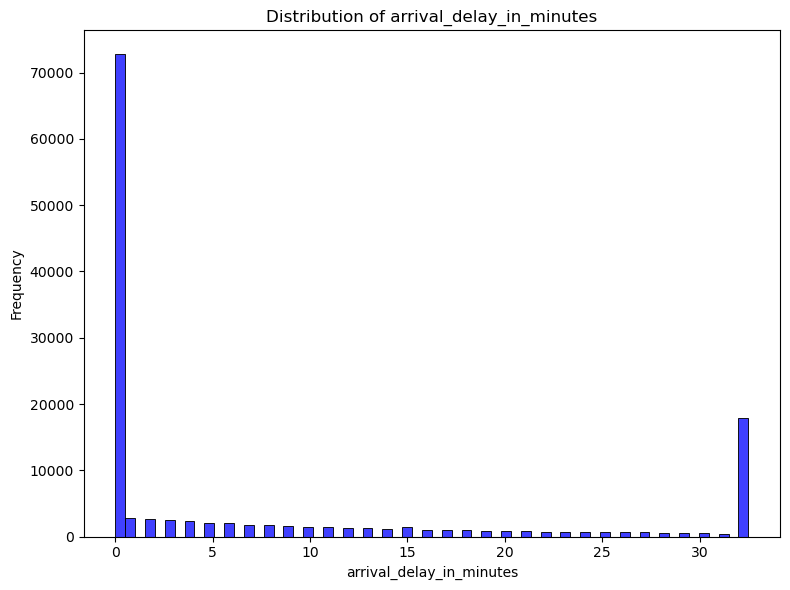

In [13]:
# plotting distribution in numerical columns
user_df.drop('id', axis =1, inplace = True) # drop the id column

# plot histogram
mf.plot_numerical_cols(user_df)

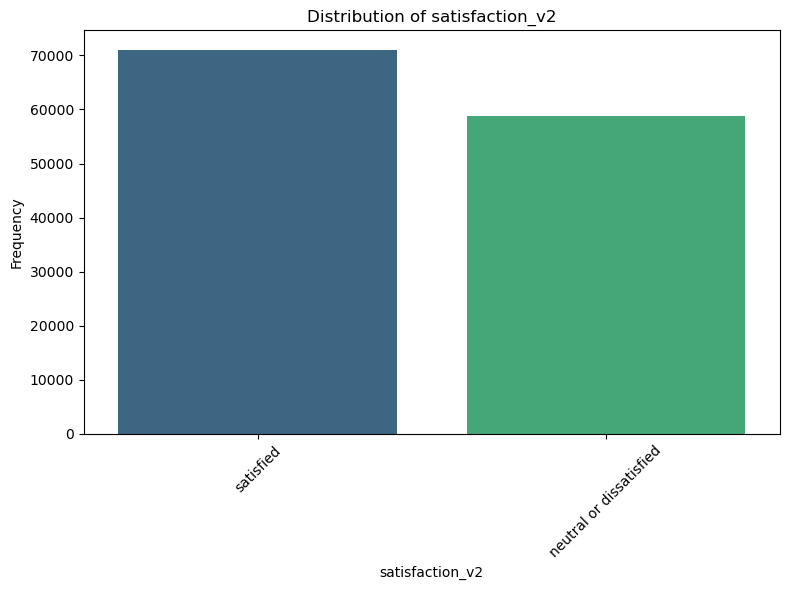

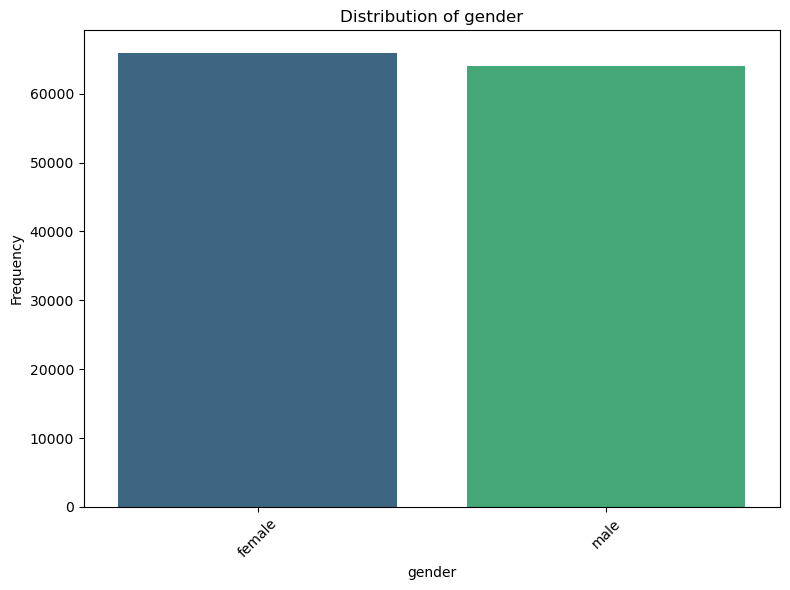

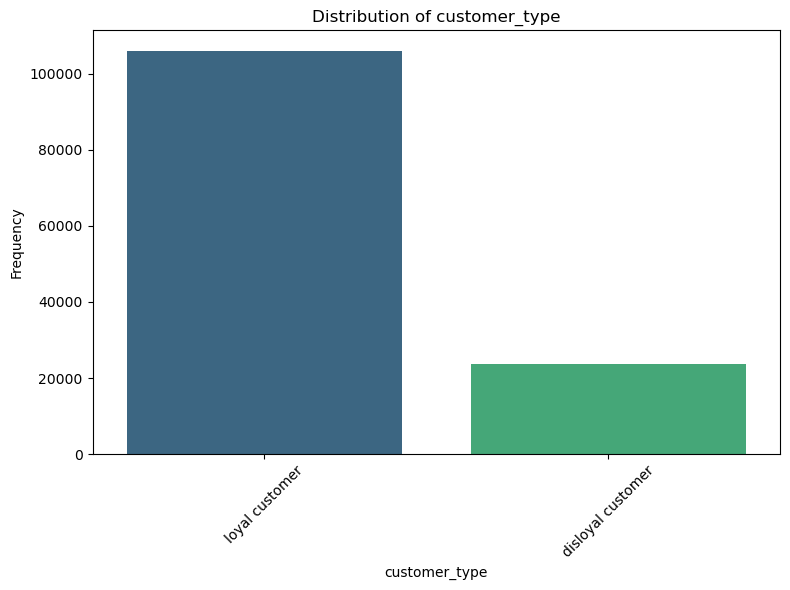

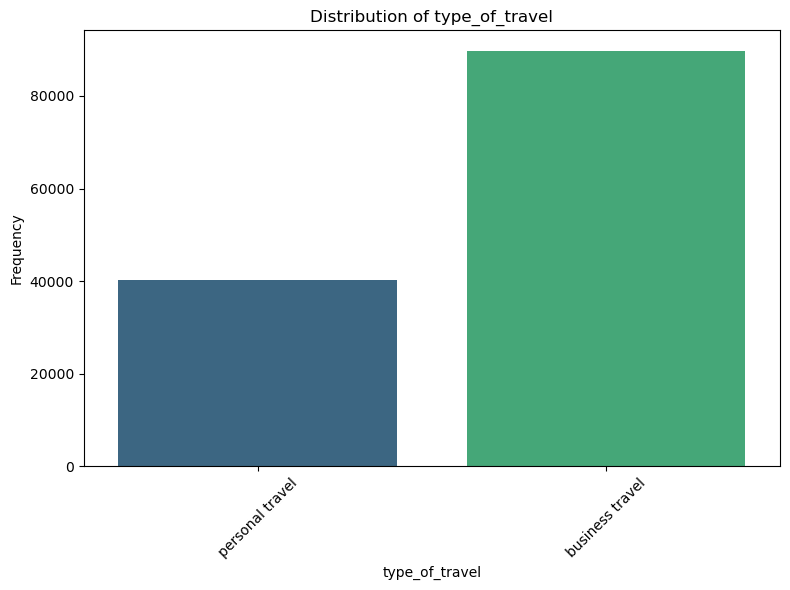

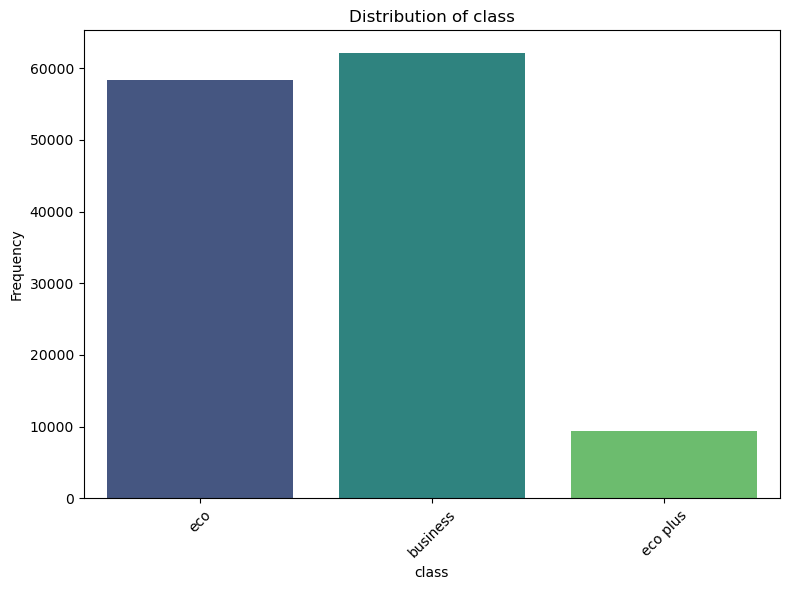

In [14]:
# plotting of distribution in categorical columns
mf.plot_categorical_cols(user_df)

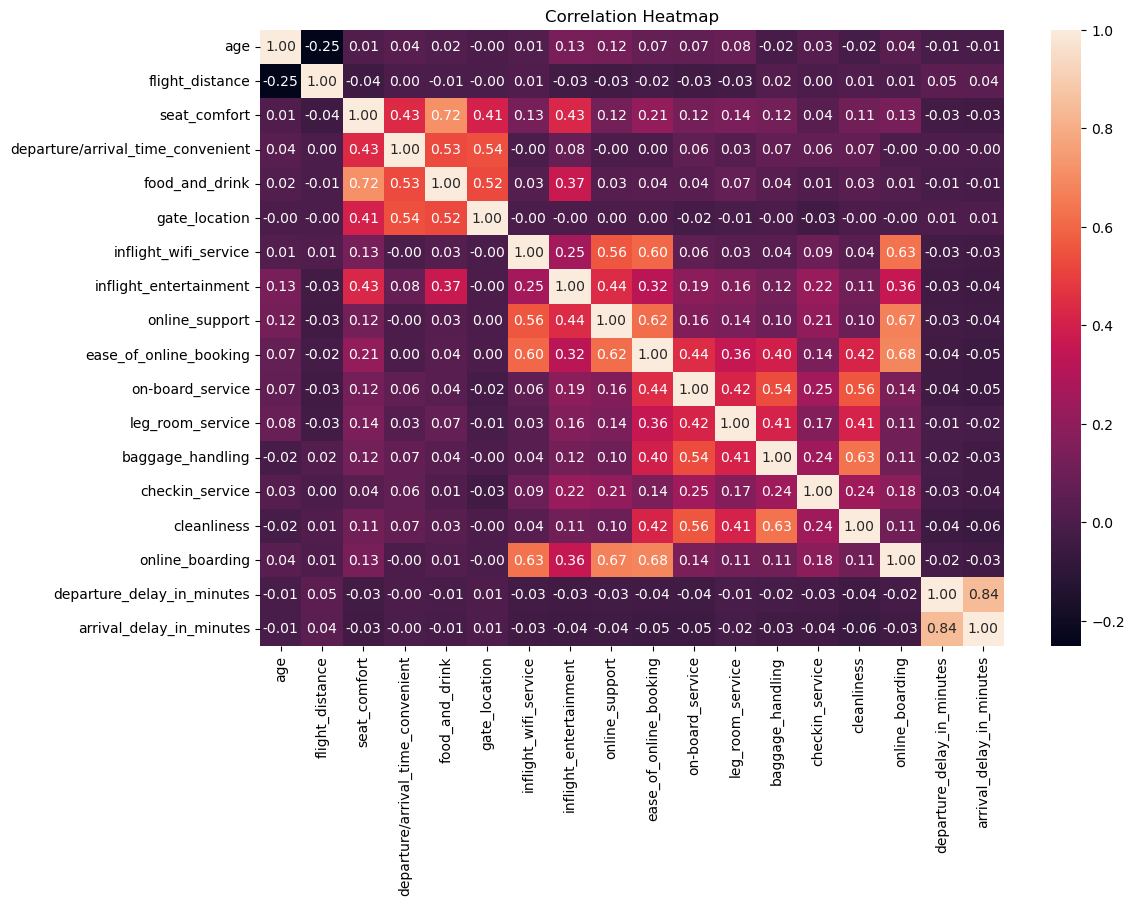

In [15]:
# create a correlation heat map
num_cols = user_df.select_dtypes(include = ['int64', 'float64']).columns
corr_matrix = user_df[num_cols].corr()

# plot the heatmap
plt.figure(figsize = (12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing for Modelling

In [16]:
# make a copy of the cleaned dataset and reset index 
model_df = user_df.copy().reset_index(drop = True) 

# view last 5 rows of the model dataset
model_df.tail()

,satisfaction_v2,gender,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,...,online_support,ease_of_online_booking,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
129875,satisfied,female,disloyal customer,29.0,personal travel,eco,1731.0,5.0,5.0,5.0,...,2.0,2.0,3.0,3.0,4.0,4.0,4.0,2.0,0.0,0.0
129876,neutral or dissatisfied,male,disloyal customer,63.0,personal travel,business,2087.0,2.0,3.0,2.0,...,1.0,3.0,2.0,3.0,3.0,1.5,2.0,1.0,30.0,32.5
129877,neutral or dissatisfied,male,disloyal customer,69.0,personal travel,eco,2320.0,3.0,0.0,3.0,...,2.0,4.0,4.0,3.0,4.0,2.0,3.0,2.0,30.0,32.5
129878,neutral or dissatisfied,male,disloyal customer,66.0,personal travel,eco,2450.0,3.0,2.0,3.0,...,2.0,3.0,3.0,2.0,3.0,2.0,1.0,2.0,30.0,32.5
129879,neutral or dissatisfied,female,disloyal customer,38.0,personal travel,eco,4307.0,3.0,4.0,3.0,...,3.0,4.0,5.0,5.0,5.0,3.0,3.0,3.0,30.0,32.5


In [17]:
# check for missing values 
model_df.isnull().sum().any()

np.False_

In [18]:
# check for duplicates
model_df.duplicated().any()

np.True_

In [19]:
# create dataframe for duplicated rows
duplicates = model_df[model_df.duplicated(keep= False)]
duplicates

,satisfaction_v2,gender,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,...,online_support,ease_of_online_booking,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
93643,satisfied,male,loyal customer,25.0,business travel,business,4321.5,5.0,5.0,5.0,...,4.0,4.0,4.0,5.0,4.0,4.0,5.0,4.0,0.0,0.0
95220,satisfied,male,loyal customer,25.0,business travel,business,4321.5,5.0,5.0,5.0,...,4.0,4.0,4.0,5.0,4.0,4.0,5.0,4.0,0.0,0.0


## Encoding Categorical Variables

In [20]:
# list categorical columns to encode
categorical_cols = model_df.select_dtypes(include = ['object']).columns
categorical_cols 

Index(['satisfaction_v2', 'gender', 'customer_type', 'type_of_travel',
       'class'],
      dtype='object')

In [21]:
# encode categorical columns using the one-hot  encoding
dummy_df = pd.get_dummies(model_df, columns= categorical_cols, drop_first= True)

#view the last 5 rows of the dummy dataset
dummy_df.tail()

,age,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,...,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction_v2_satisfied,gender_male,customer_type_loyal customer,type_of_travel_personal travel,class_eco,class_eco plus
129875,29.0,1731.0,5.0,5.0,5.0,3.0,2.0,5.0,2.0,2.0,...,4.0,2.0,0.0,0.0,True,False,False,True,True,False
129876,63.0,2087.0,2.0,3.0,2.0,4.0,2.0,1.0,1.0,3.0,...,2.0,1.0,30.0,32.5,False,True,False,True,False,False
129877,69.0,2320.0,3.0,0.0,3.0,3.0,3.0,2.0,2.0,4.0,...,3.0,2.0,30.0,32.5,False,True,False,True,True,False
129878,66.0,2450.0,3.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,...,1.0,2.0,30.0,32.5,False,True,False,True,True,False
129879,38.0,4307.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,...,3.0,3.0,30.0,32.5,False,False,False,True,True,False


In [22]:
# overview of the final dataframe for model building 
dummy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   age                                129880 non-null  float64
 1   flight_distance                    129880 non-null  float64
 2   seat_comfort                       129880 non-null  float64
 3   departure/arrival_time_convenient  129880 non-null  float64
 4   food_and_drink                     129880 non-null  float64
 5   gate_location                      129880 non-null  float64
 6   inflight_wifi_service              129880 non-null  float64
 7   inflight_entertainment             129880 non-null  float64
 8   online_support                     129880 non-null  float64
 9   ease_of_online_booking             129880 non-null  float64
 10  on-board_service                   129880 non-null  float64
 11  leg_room_service                   1298

In [23]:
X = dummy_df.drop(columns=['satisfaction_v2_satisfied'], axis=1)
print(X.columns.tolist())

['age', 'flight_distance', 'seat_comfort', 'departure/arrival_time_convenient', 'food_and_drink', 'gate_location', 'inflight_wifi_service', 'inflight_entertainment', 'online_support', 'ease_of_online_booking', 'on-board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding', 'departure_delay_in_minutes', 'arrival_delay_in_minutes', 'gender_male', 'customer_type_loyal customer', 'type_of_travel_personal travel', 'class_eco', 'class_eco plus']


# Model Building

In [24]:
# check for class imbalance in the target variable
dummy_df['satisfaction_v2_satisfied'].value_counts(normalize= True) * 100

satisfaction_v2_satisfied
True     54.73283
False    45.26717
Name: proportion, dtype: float64

## Splitting Dataset Into Train Test Set

In [25]:
# set seed value for reproducity
s = 101

# declare response /target variable
y = dummy_df['satisfaction_v2_satisfied']

# declare feature variables 
X = dummy_df.drop(columns = ['satisfaction_v2_satisfied'], axis = 1)

# split dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = s, stratify = y)

In [26]:
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (103904, 23)
Shape of X_test : (25976, 23)
Shape of y_train : (103904,)
Shape of y_test : (25976,)


# 1.Model Training- RandomForestClassifier (rfc) 

In [27]:
# instantiate the model
rfc = RandomForestClassifier(random_state =s)

# fit the model using the training dataset
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predicting and Evaluation

               precision    recall  f1-score   support

Not Satisfied       0.94      0.96      0.95     11759
    Satisfied       0.97      0.95      0.96     14217

     accuracy                           0.96     25976
    macro avg       0.95      0.96      0.95     25976
 weighted avg       0.96      0.96      0.96     25976
 



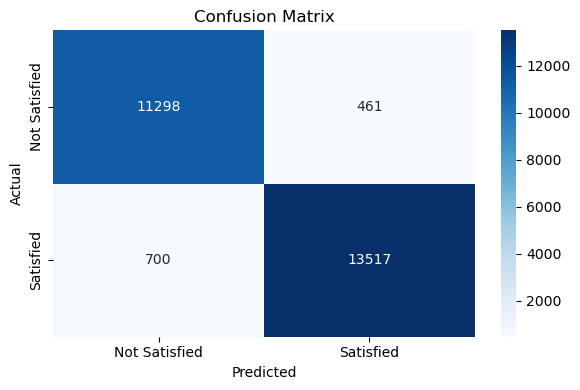

In [28]:
# Predict using the test set
rfc_y_predict = rfc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, rfc_y_predict)

# Print classification report with target names
print(classification_report(y_test, rfc_y_predict, target_names=["Not Satisfied", "Satisfied"]), '\n')

# Plot heatmap with target names on axes
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning Model (rfc)

In [29]:
# instantiate model
#model = RandomForestClassifier(random_state = s)

# set parameter grid
#param_grid = {
#    'criterion': ["gini", "entropy", "log_loss"],
#    'n_estimators': [10, 50, 100],
#    'max_depth': [None, 5, 10],
#    'max_features': ["sqrt", "log2", None],
#    'class_weight': [None, 'balanced'] 
#}

# GridSearchCV with recall scoring and random_state set
#grid_search = GridSearchCV(param_grid = param_grid, estimator = model, scoring = 'recall', \
#                          n_jobs = -1, cv =5, error_score='raise', verbose = 2)

# Fit grid search
#grid_search.fit(X_train, y_train)

# Print best parameters 
#print(grid_search.best_params_)

## Rebuild Model Using Best Parameters 

In [30]:
# instantiate the model
rfc1 = RandomForestClassifier(criterion = 'gini', n_estimators =100, max_depth = None , \
                               max_features = 'sqrt', random_state = s, class_weight = 'balanced' )

# fit the model using the training dataset
rfc1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predicting and Evaluation (rfc_1)

               precision    recall  f1-score   support

Not Satisfied       0.94      0.96      0.95     11759
    Satisfied       0.97      0.95      0.96     14217

     accuracy                           0.96     25976
    macro avg       0.96      0.96      0.96     25976
 weighted avg       0.96      0.96      0.96     25976
 



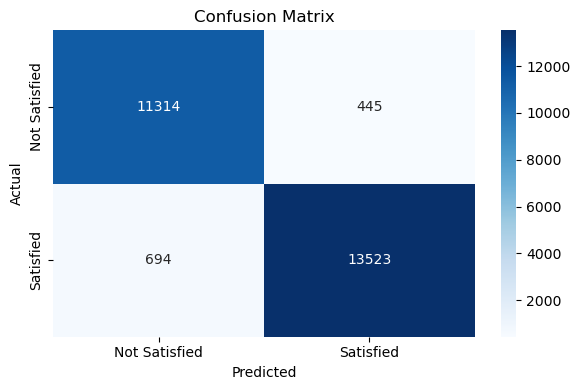

In [31]:
# Predict using the test set
rfc1_y_predict = rfc1.predict(X_test)

# model evaluation
cm = confusion_matrix(y_test, rfc1_y_predict) # Get confusion matrix
print(classification_report(y_test, rfc1_y_predict, target_names= ["Not Satisfied", "Satisfied"]), '\n') # Classification report

# Plot heatmap with target names on axes
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
# Create DataFrame with actual and predicted values
comparison_df = pd.DataFrame({'Actual': y_test.values,'Predicted': rfc1_y_predict})

# Display first few rows
comparison_df.head()

,Actual,Predicted
0,True,True
1,False,False
2,False,False
3,False,False
4,True,True


In [33]:
# Find rows where prediction is different from actual
mismatches = comparison_df[comparison_df['Actual'] != comparison_df['Predicted']]

# Show the mismatched predictions
mismatches.head()

,Actual,Predicted
24,True,False
38,True,False
77,False,True
125,True,False
151,True,False


### Feature Importance 

In [34]:
# lets get the features and their importance
feature_importances = rfc1.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})

# Convert importance to percentage
importance_df["Importance (%)"] = (importance_df["Importance"] / importance_df["Importance"].sum()) * 100

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(5)

,Feature,Importance,Importance (%)
7,inflight_entertainment,0.198386,19.838599
2,seat_comfort,0.131531,13.153079
9,ease_of_online_booking,0.076368,7.636810
8,online_support,0.069334,6.933445
10,on-board_service,0.045766,4.576628


# 2.Model Training - DecisionTreeClassifier (dtc)

In [35]:
# instantiate the model
dtc= DecisionTreeClassifier(random_state =s )

# fit the model using the training dataset
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,101
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction and Evaluation

               precision    recall  f1-score   support

Not Satisfied       0.93      0.93      0.93     11759
    Satisfied       0.94      0.94      0.94     14217

     accuracy                           0.94     25976
    macro avg       0.94      0.94      0.94     25976
 weighted avg       0.94      0.94      0.94     25976
 



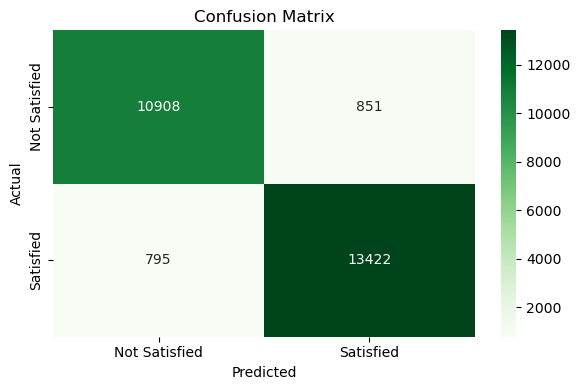

In [36]:
# Predict using the test set
dtc_y_predict = dtc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, dtc_y_predict)

# Print classification report with target names
print(classification_report(y_test, dtc_y_predict, target_names=["Not Satisfied", "Satisfied"]), '\n')

# Plot heatmap with target names on axes
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning Model (dtc1)

In [37]:
# instantiate model
#model = DecisionTreeClassifier(random_state = s)

#param_grid = {
#    'criterion': ["gini", "entropy"],
#    'splitter': ["best", "random"],
#    'max_depth': [5, 10],
#    'max_features': ["sqrt", "log2", 0.1],
#    'class_weight': [None, 'balanced']
#}

# GridSearchCV with recall scoring and random_state set
#grid_search = GridSearchCV(param_grid = param_grid, estimator = model, scoring = 'recall', \
#                          n_jobs = -1, cv =5, error_score='raise', verbose =2)

# Fit grid search
#grid_search.fit(X_train, y_train)

# Print best parameters 
#print(grid_search.best_params_)

## Rebuild Model ( dtc_1) Using Best Parameters 

In [38]:
# instantiate the model
dtc1 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10 , max_features = 'sqrt', \
                                splitter = 'best', random_state =s, class_weight = None )

# fit the model using the training dataset
dtc1.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,101
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


               precision    recall  f1-score   support

Not Satisfied       0.90      0.88      0.89     11759
    Satisfied       0.90      0.92      0.91     14217

     accuracy                           0.90     25976
    macro avg       0.90      0.90      0.90     25976
 weighted avg       0.90      0.90      0.90     25976
 



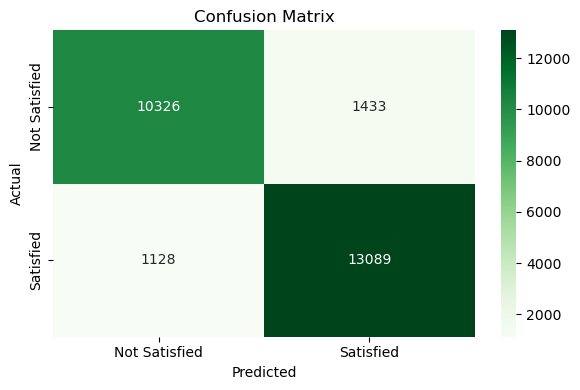

In [39]:
# Predict using the test set
dtc1_y_predict = dtc1.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, dtc1_y_predict)

# Print classification report with target names
print(classification_report(y_test, dtc1_y_predict, target_names=["Not Satisfied", "Satisfied"]), '\n')

# Plot heatmap with target names on axes
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [40]:
# lets get the features and their importance
feature_importances = dtc.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})

# Convert importance to percentage
importance_df["Importance (%)"] = (importance_df["Importance"] / importance_df["Importance"].sum()) * 100

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head()

,Feature,Importance,Importance (%)
7,inflight_entertainment,0.392668,39.266759
2,seat_comfort,0.179435,17.943549
9,ease_of_online_booking,0.056047,5.604666
1,flight_distance,0.042336,4.233550
3,departure/arrival_time_convenient,0.030531,3.053069


# Saving the best model ( random forest classifier)

In [41]:
import pickle

# saving the model (serialization)
with open('best_model.pkl', 'wb') as m:
    pickle.dump(rfc1, m)

In [42]:
# loading back the model (deserialization)
with open('best_model.pkl', 'rb') as r:
    loaded_model = pickle.load(r)

In [43]:
# compressing pickle file size to suit github maximum pickle file size
import joblib

# save with compression (level 3 is a good balance of size vs speed)
joblib.dump(rfc1, 'best_model.pkl', compress=3)

['best_model.pkl']